# DES Y6: exploring the 3×2pt data vector

This notebook evaluates the DES Y6 **3×2pt** model of `EXAMPLE_EVALUATE1.yaml` and plots its predictions. "3×2pt" names three two-point functions measured between two galaxy samples:

| Probe | What is correlated | Plotted here |
|---|---|---|
| Cosmic shear | shapes of source galaxies with shapes of source galaxies | spectra $C_\ell^{EE}$, correlation functions ξ+(θ) and ξ−(θ) |
| Galaxy–galaxy lensing | positions of lens galaxies with shapes of source galaxies | tangential shear γt(θ) |
| Galaxy clustering | positions of lens galaxies with positions of lens galaxies | spectra $C_\ell^{gg}$ and correlation function w(θ) |

**Source** galaxies are the galaxies whose shapes are distorted by weak gravitational lensing; DES Y6 splits them into four redshift bins. **Lens** galaxies trace the matter distribution through their positions; they form six redshift bins. Splitting a sample into redshift bins is called **tomography**. Figure labels number the bins from 1; arrays index them from 0.

Each correlation function is measured in 26 logarithmic angular bins from 2.5 to 995.27 arcmin. Stacked, they form the 1,300-entry **data vector**: ξ+ (10 source-bin pairs × 26 = 260 entries), ξ− (260), γt (24 lens–source pairs × 26 = 624) and w (6 lens bins × 26 = 156).

**The active data vector is a dummy vector with a unit (identity) covariance.** The figures show theoretical predictions, not a fit to DES Y6 measurements, and the likelihood value has no statistical meaning. `EXAMPLE_EVALUATE_COVARIANCE.ipynb` constructs an analogous covariance forecast.

Run `source start_cocoa.sh` before launching Jupyter, select the Cocoa Python kernel (the Python process that runs these cells) and export `OMP_NUM_THREADS` in the same terminal, for example `export OMP_NUM_THREADS=8`. Run the cells in order. Build only one model per kernel: the compiled Cosmolike library keeps a single global state per process.


## Set up the kernel

The next cell prepares the session:

- It reads `OMP_NUM_THREADS`, the number of OpenMP threads the compiled loops use, and stops unless the value is a positive integer.
- It requires `ROOTDIR`, the `cocoa/Cocoa` folder exported by `start_cocoa.sh`, and puts two folders first on Python's import path. `projects/des_y6/interface` holds the compiled module `cosmolike_des_y6_interface` and the notebook module `des_y6_notebook.py`, which defines `build_model` and `evaluate`. `external_modules/code/cosmolike_core` holds the shared plotting package `cosmolike_notebook_utils`, imported as `cnu`.
- Importing `des_y6_notebook` also imports the compiled module. An `ImportError` there means the project has not been compiled; follow the compilation steps in the project README.

The `matplotlib.rcParams` lines choose fonts and sizes for every figure; the shared plotting functions never change them.


In [1]:
# Draw figures inside the notebook.
%matplotlib inline
import os
import sys
from pathlib import Path

# OpenMP threads of the compiled loops, read from the shell that started
# Jupyter; 1 when OMP_NUM_THREADS is unset.
threads = int(os.environ.get("OMP_NUM_THREADS", "1"))
if threads < 1:
    raise ValueError("Set OMP_NUM_THREADS to a positive integer before starting Jupyter.")
if "ROOTDIR" not in os.environ:
    raise RuntimeError("Start this kernel from the environment loaded by start_cocoa.sh.")

# Position 0 puts the project interface and cosmolike_core ahead of any
# installed package with the same module names.
cocoa = Path(os.environ["ROOTDIR"]).resolve()
sys.path.insert(0, str(cocoa / "projects/des_y6/interface"))
sys.path.insert(0, str(cocoa / "external_modules/code/cosmolike_core"))

import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import cosmolike_notebook_utils as cnu
# This import also loads the compiled module; ImportError means it is not built.
from des_y6_notebook import build_model, evaluate

# Fonts and sizes belong to the notebook; the shared plotters never set them.
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["font.serif"] = ["STIXGeneral"]
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams["figure.dpi"] = 100
matplotlib.rcParams["axes.linewidth"] = 1.0
matplotlib.rcParams["axes.labelsize"] = 12
matplotlib.rcParams["legend.fontsize"] = 11

print(f"Cosmolike OpenMP threads: {threads}")


Cosmolike OpenMP threads: 8


## Build the model from the YAML

`build_model(example=1)` reads `EXAMPLE_EVALUATE1.yaml` and hands it to **Cobaya**, the framework that connects theory codes with likelihoods. The resulting model joins Cobaya's CAMB theory with the `des_y6.combo_3x2pt` likelihood. Building it runs the likelihood's initialization once: it reads `data/DESY6.dataset`, which names the two n(z) files, the 26 angular bins, the dummy data vector, the identity covariance and `ones.mask`, a mask that keeps all 1,300 entries.

Each n(z) file tabulates the redshift distribution of every bin, with the **lower edge** of each histogram bin in the first column; the YAML's `photoz_zmid_convention: 0` selects that reading.

`fiducial` holds every sampled parameter, with the values of the YAML's `evaluate.override` block. The next cell prints the cosmological ones:

| Parameter | Meaning | Fiducial |
|---|---|---|
| `omegam`, `omegab` | Density parameters of total matter (massive neutrinos included) and of baryons today | 0.319, 0.049 |
| `H0` | Hubble constant in km s⁻¹ Mpc⁻¹ | 67.0 |
| `As_1e9` | $10^9 A_s$, with $A_s$ the amplitude of the primordial curvature power spectrum at k = 0.05 Mpc⁻¹ | 2.1 |
| `ns` | Spectral index of that power spectrum | 0.96 |
| `mnu` | Sum of the three neutrino masses, in eV | 0.06 |
| `w`, `w0pwa` | Dark-energy equation of state today, $w_0$, and $w_0+w_a$ | −1, −1 |

The nuisance parameters describe the galaxy samples and the shape measurement:

| Parameters | Meaning | Fiducial |
|---|---|---|
| `DES_B1_1` … `DES_B1_6` | Linear galaxy bias $b_1$ of each lens bin: galaxy overdensity = $b_1$ × matter overdensity | 1.54, 1.81, 1.85, 1.76, 1.93, 1.90 |
| `DES_DZ_L1` … `DES_DZ_L6`, `DES_DZ_S1` … `DES_DZ_S4` | Shifts Δz of the lens and source redshift distributions | 0 |
| `DES_M1` … `DES_M4` | Multiplicative shear calibration m of each source bin: measured shear = (1 + m) × true shear | −0.0034, 0.0065, 0.0159, 0.0017 |
| `DES_A1_1`, `DES_A1_2` | Amplitude $A_1$ and redshift index η of the intrinsic-alignment model | 0.769, −1 |

**Intrinsic alignments** (IA) are correlations between galaxy shapes produced by tidal fields rather than by lensing. With `IA_model: 0` (NLA, the nonlinear alignment model) and `IA_redshift_evolution: 3`, the amplitude at redshift z is $A_1\,[(1+z)/1.62]^{\eta}$, a power law around the pivot z = 0.62. The point-mass, higher-order bias and magnification parameters stay at zero, the values fixed in `likelihood/params_lens.yaml`.


## Evaluate three primordial amplitudes

The next cell evaluates the model at $10^9 A_s$ = 1.9, 2.1 and 2.3, with every other parameter at its fiducial value; `results[1]` is the fiducial prediction. Each call `evaluate(model, point, ell, clustering=True)` runs Cobaya's `model.loglikes`, which executes the likelihood pipeline in this order:

| Stage | Code | Result |
|---|---|---|
| 1. CAMB | Cobaya's CAMB theory | Linear and nonlinear matter power spectra P(k, z), with HMcode 2020 and its baryonic-feedback parameter log₁₀ T_AGN = 7.7; comoving distances; the neutrino density $\Omega_\nu h^2$ |
| 2. `set_cosmology` | likelihood method `set_cosmo_related` | Copies ln P in (Mpc/h)³ on fixed (k, z) grids, the growth factor and the distances in Mpc/h into Cosmolike |
| 3. Nuisance setters | likelihood methods `set_lens_related` and `set_source_related` | Install $b_1$, the redshift shifts, m and the IA parameters through `ci.set_nuisance_bias`, `ci.set_nuisance_clustering_photoz`, `ci.set_point_mass`, `ci.set_nuisance_shear_calib`, `ci.set_nuisance_shear_photoz` and `ci.set_nuisance_ia` |
| 4. Data vector | `ci.compute_data_vector_masked` | The 1,300 predictions, compared with the dummy data |
| 5. Wrapper arrays | `ci.C_ss_tomo_limber`, `ci.xi_pm_tomo`, `ci.C_gs_tomo_limber`, `ci.C_gg_tomo`, `ci.w_gammat_tomo`, `ci.w_gg_tomo` | Spectra and correlation functions as NumPy arrays |

Here `ci` is the compiled module. Its wrappers read the cosmology and nuisance state installed by stages 2 and 3, so their arrays belong to the last evaluated point; `evaluate` copies them, so earlier results keep their values.

Stage 4 multiplies ξ± by $(1+m_i)(1+m_j)$ and γt by $(1+m_j)$, one factor per source bin j. The wrapper arrays of stage 5 omit these factors, so the plotted curves exclude the shear calibration.

The multipoles `ell` run from 30 to 1500 in steps of 15, 99 values. Every array is dimensionless except `theta_arcmin`:

| Key of `result` | Axes |
|---|---|
| `C_ss`, `C_BB` | (multipole, source bin, source bin): E- and B-mode shear spectra |
| `C_gs` | (multipole, lens bin, source bin) |
| `C_gg` | (multipole, lens bin, lens bin), auto-bin entries only |
| `theta_arcmin` | (angular bin): one representative angle per bin, in arcmin |
| `xi_plus`, `xi_minus` | (angular bin, source bin, source bin) |
| `gammat` | (angular bin, lens bin, source bin) |
| `wtheta` | (angular bin, lens bin, lens bin), auto-bin entries only |
| `data_vector` | 1,300 entries in the order ξ+, ξ−, γt, w |


In [2]:
# Runs the likelihood's one-time initialization; fiducial maps each sampled
# parameter to its value in the YAML's evaluate.override block.
model, fiducial = build_model(example=1)
print("Fiducial cosmology from EXAMPLE_EVALUATE1.yaml:")
for name in ("omegam", "omegab", "H0", "As_1e9", "ns", "mnu", "w", "w0pwa"):
    print(f"  {name}: {fiducial[name]}")

# 99 multipoles from 30 to 1500. They are integer-valued floats because the
# non-Limber clustering lookup below ell = 150 reads integer multipoles.
ell = np.arange(30.0, 1501.0, 15.0)
# 10^9 A_s values; 2.1 is the YAML fiducial, so results[1] is the fiducial.
amplitudes = [1.9, 2.1, 2.3]
results = []
for amplitude in amplitudes:
    # dict() makes a copy, so fiducial keeps its YAML values.
    point = dict(fiducial)
    point["As_1e9"] = amplitude
    # Reruns CAMB and the likelihood, then copies the wrapper arrays.
    result = evaluate(model=model, point=point, ell=ell, clustering=True)
    results.append(result)

# Shapes (multipole, source, source) and (angle, source, source); 1,300 entries.
print("C_ell shear array:", results[1]["C_ss"].shape)
print("xi_plus array:", results[1]["xi_plus"].shape)
print("Masked-vector storage:", results[1]["data_vector"].size)



Classy could not be found in your system.
Here are some suggestions:

	 -Download the Class from class-code.net and install it
	  together with its wrapper classy (type 'make' instead of
	  'make class'
	 -If you know that Class is installed on your system
	  and yet classy could not be installed, try re-compiling
	  Class with just ''make'' instead of ''make class''
NOTICE: Even without classy you can still use EuclidEmulator2
        to emulate boost factors. You won't be able to compute
        full power spectra, though.
[camb] `camb` module loaded successfully from /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/external_modules/code/CAMB/camb


[des_y6.combo_3x2pt] use_baryon_pca = False


Fiducial cosmology from EXAMPLE_EVALUATE1.yaml:
  omegam: 0.319
  omegab: 0.049
  H0: 67.0
  As_1e9: 2.1
  ns: 0.96
  mnu: 0.06
  w: -1
  w0pwa: -1


C_ell shear array: (99, 4, 4)
xi_plus array: (26, 4, 4)
Masked-vector storage: 1300


## Plot the shear power spectra

The **angular power spectrum** $C_\ell$ decomposes a correlation on the sky into multipoles ℓ; a multipole ℓ corresponds to angular scales near 180°/ℓ. `C_ss` holds the E-mode shear spectra $C_\ell^{EE}$ of every pair of source bins. The E mode is the curl-free part of the shear pattern, the part that lensing by matter produces.

Cosmolike computes these spectra with the **Limber approximation**, which keeps only Fourier modes perpendicular to the line of sight. Its error shrinks as ℓ grows and as the radial weight of a bin widens; lensing weights are broad in redshift.

Each panel is one source-bin pair of the lower triangle: the panel labeled (i, j) draws `C_ss[:, i-1, j-1]` with i ≤ j, and the wrapper leaves the mirrored entries zero. The y axis shows $\ell(\ell+1)C_\ell/2\pi$ on a logarithmic scale, and the color bar gives $10^9 A_s$. The spectra include NLA intrinsic alignments but not the shear calibration factors.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


...

[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


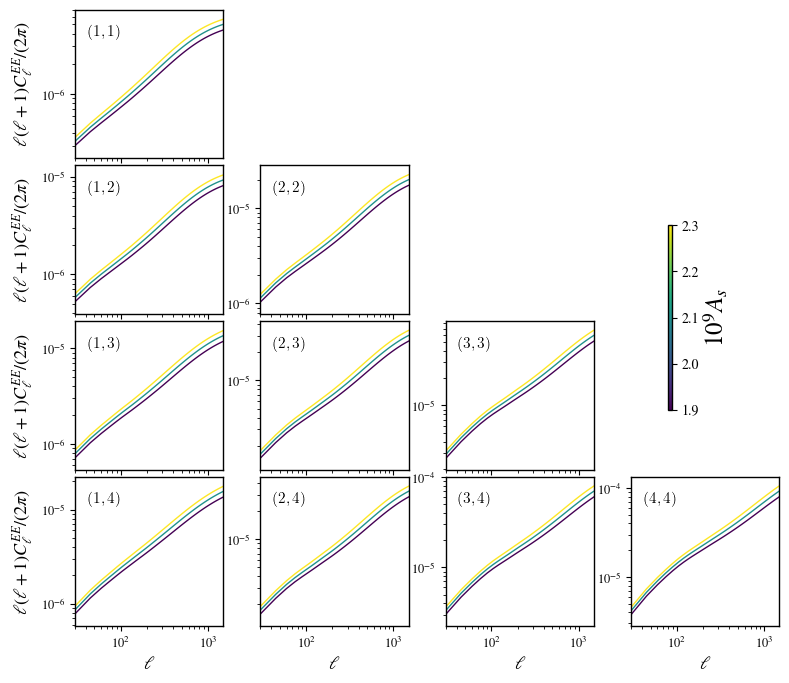

In [3]:
shear_spectra = []
shear_correlations = []
for result in results:
    shear_spectra.append(result["C_ss"])
    # plot_xi takes one (theta_arcmin, xi_plus, xi_minus) tuple per curve.
    shear_correlations.append((
        result["theta_arcmin"],
        result["xi_plus"],
        result["xi_minus"],
    ))
cnu.plot_C_ss_tomo_limber(
    ell=ell,
    C_ss=shear_spectra,
    param=amplitudes,
    colorbarlabel=r"$10^9 A_s$",
    lmin=30,
    lmax=1500,
    cmap="viridis",
    figsize=(9, 8),
    bintextsize=11,
    xaxislabelsize=13,
    yaxislabelsize=13,
    xaxisticklabelsize=9,
    yaxisticklabelsize=9,
)


## Plot the shear correlation functions ξ+ and ξ−

For galaxy pairs separated by θ, split each galaxy's shear into a tangential and a cross component relative to the line joining the pair. The correlation functions are $\xi_\pm(\theta)=\langle\gamma_t\gamma_t\rangle\pm\langle\gamma_\times\gamma_\times\rangle$. Cosmolike obtains them from the spectra: ξ+ sums $C_\ell^{EE}+C_\ell^{BB}$ and ξ− sums $C_\ell^{EE}-C_\ell^{BB}$ over multipoles up to ℓ = 50,000 (the YAML's `lmax`), with Legendre-polynomial weights averaged exactly over each angular bin.

Each panel is one source-bin pair, as for the spectra above. The x coordinate is the area-weighted mean angle of each bin, $\theta=\frac{2}{3}\,\frac{\theta_{\max}^3-\theta_{\min}^3}{\theta_{\max}^2-\theta_{\min}^2}$, in arcmin. The y axis shows θ ξ × 10⁴, with θ in arcmin, on a linear scale.

These arrays come from the ordinary data-vector routine `ci.xi_pm_tomo`, not from the covariance module's spectra, and they exclude the shear calibration factors.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


...

[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


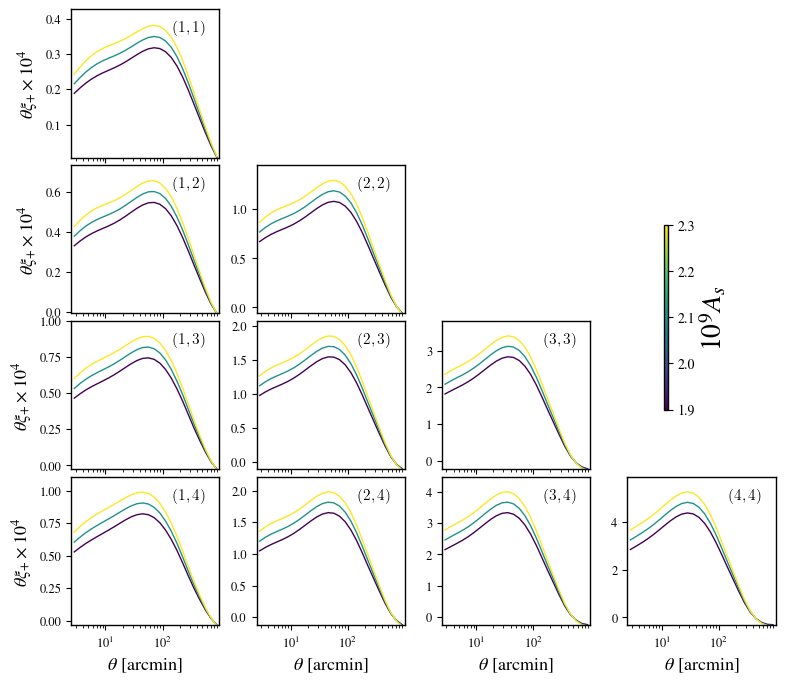

In [4]:
cnu.plot_xi(
    # pm=1 draws xi+, pm=-1 draws xi-.
    pm=1,
    xi=shear_correlations,
    param=amplitudes,
    colorbarlabel=r"$10^9 A_s$",
    # x-axis range in arcmin: the outer edges of the 26 angular bins.
    thetashow=[2.5, 995.2679263837432],
    cmap="viridis",
    figsize=(9, 8),
    bintextsize=11,
    xaxislabelsize=13,
    yaxislabelsize=13,
    xaxisticklabelsize=9,
    yaxisticklabelsize=9,
)


The next figure shows ξ− with the same layout. In the flat-sky limit the ξ+ weight is the Bessel function $J_0(\ell\theta)$ and the ξ− weight is $J_4(\ell\theta)$, which peaks at larger ℓθ. At a given angle, ξ− therefore responds to higher multipoles, that is, to smaller physical scales where the matter power spectrum is nonlinear.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


...

[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


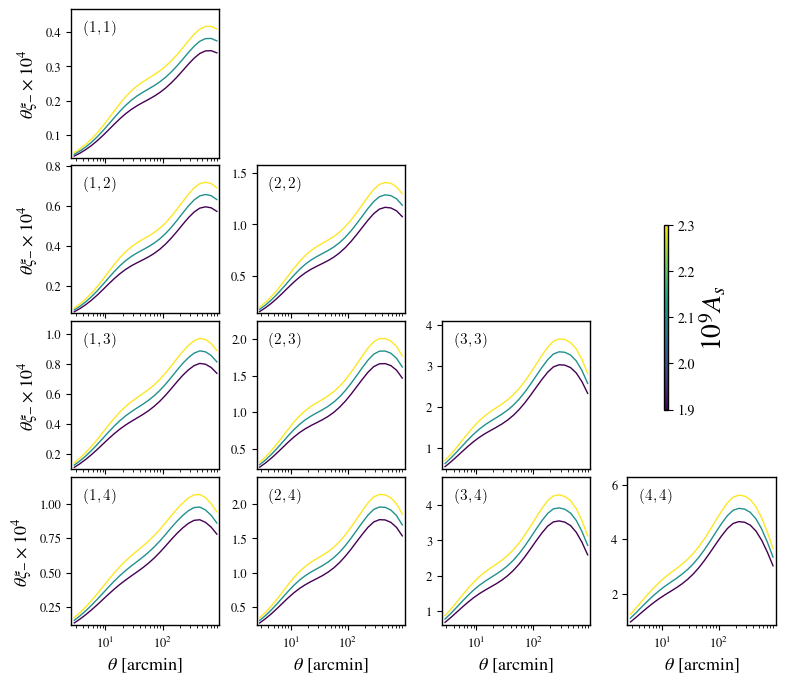

In [5]:
cnu.plot_xi(
    pm=-1,
    xi=shear_correlations,
    param=amplitudes,
    colorbarlabel=r"$10^9 A_s$",
    thetashow=[2.5, 995.2679263837432],
    cmap="viridis",
    figsize=(9, 8),
    bintextsize=11,
    xaxislabelsize=13,
    yaxislabelsize=13,
    xaxisticklabelsize=9,
    yaxisticklabelsize=9,
)


## Plot galaxy–galaxy lensing γt

**Galaxy–galaxy lensing** is the tangential shear γt(θ) of source galaxies at angular distance θ from lens galaxies: the matter around the lenses bends the light of the sources behind them. It measures the galaxy–matter cross-correlation, which in this linear-bias model is $b_1$ times the matter correlation.

`gammat` has axes (angular bin, lens bin, source bin). The figure has one row per source bin and one column per lens bin; the panel labeled (i, j) means lens bin i and source bin j, counting from 1, and draws `gammat[:, i-1, j-1]`. All 24 pairs are computed, so pairs with little redshift overlap show small signals. The y axis shows the absolute value |γt| on a logarithmic scale.

`ci.w_gammat_tomo` follows the likelihood's `adopt_limber_gs` choice; this YAML keeps the Limber default. The arrays omit the factor $(1+m_j)$ and the point-mass term, which only the data vector adds; the point masses are zero here. `evaluate` also returns the galaxy–shear spectra `C_gs`, which this notebook does not plot; `cnu.plot_C_gs_tomo_limber` draws them on the same grid.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


...

[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


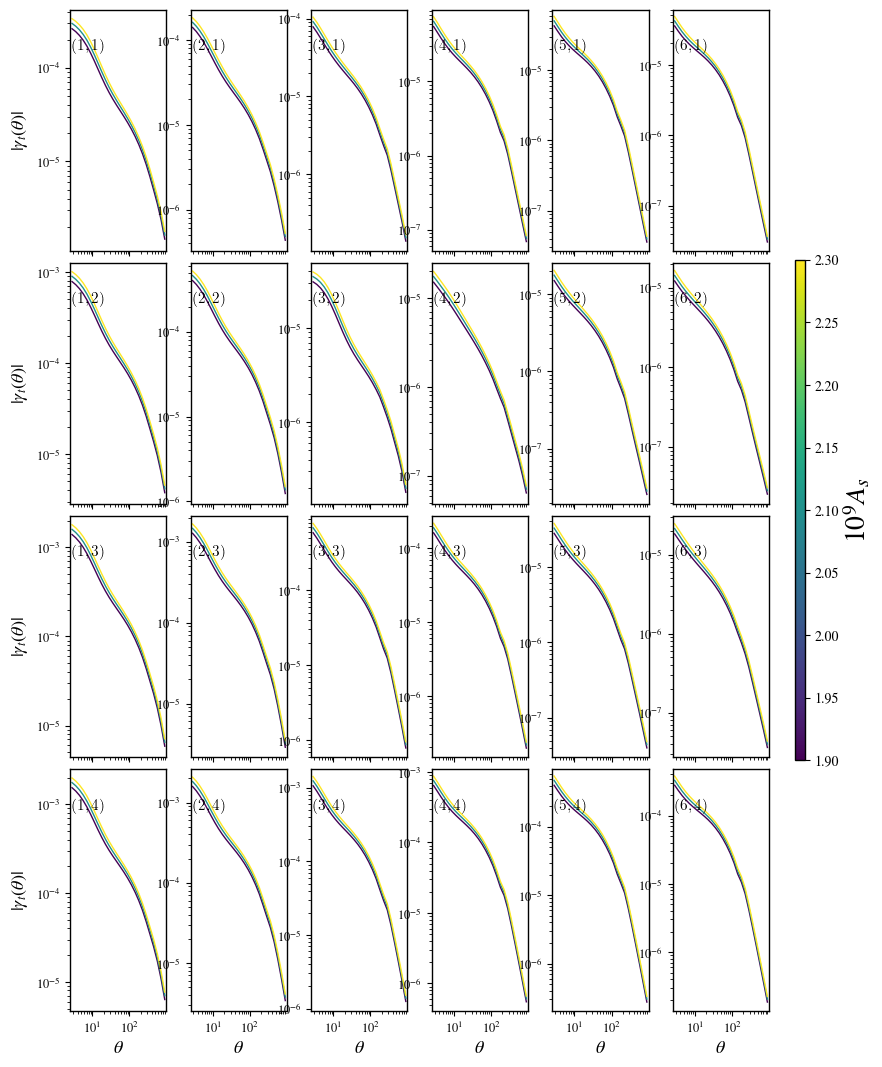

In [6]:
gammat_curves = []
for result in results:
    # One (theta_arcmin, gammat) pair per curve, as plot_gammat_tomo_limber expects.
    gammat_curves.append((result["theta_arcmin"], result["gammat"]))

cnu.plot_gammat_tomo_limber(
    theta_gammat=gammat_curves,
    param=amplitudes,
    colorbarlabel=r"$10^9 A_s$",
    thetashow=[2.5, 995.2679263837432],
    cmap="viridis",
    figsize=(11, 13),
    bintextsize=11,
    xaxislabelsize=13,
    yaxislabelsize=13,
    xaxisticklabelsize=9,
    yaxisticklabelsize=9,
)


## Plot galaxy clustering before and after the angular transform

**Galaxy clustering** correlates the positions of lens galaxies within one lens bin. The angular correlation function w(θ) is the excess probability, relative to a random distribution, of finding two lens galaxies at separation θ. In the linear-bias model it follows $b_1^2$ times the projected matter correlation, plus redshift-space distortions (RSD), the line-of-sight displacement of galaxies by their peculiar velocities. Lens magnification is off: `DES_BMAG_*` = 0.

The likelihood computes clustering spectra without the Limber approximation below ℓ = 150 (`adopt_limber_gg: 0`), because the approximation fails for narrow lens bins at low multipoles; each bin switches to Limber once the two agree within 1%. `evaluate` therefore calls `ci.C_gg_tomo`, which repeats that choice and needs the integer-valued `ell`.

The arrays have axes (multipole or angular bin, lens bin, lens bin); only the six auto-bin entries (i, i) are filled, and each panel shows one lens bin. The first figure shows $C_\ell^{gg}$ itself, without the $\ell(\ell+1)/2\pi$ factor, on a logarithmic axis. The second shows |w(θ)| on a logarithmic axis, so a dip toward zero can mark a sign change at large θ.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


...

[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


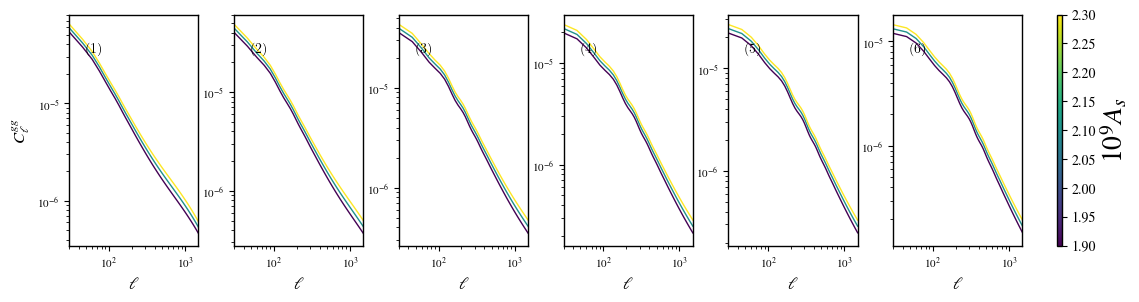

In [7]:
clustering_spectra = []
clustering_correlations = []
for result in results:
    clustering_spectra.append(result["C_gg"])
    # One (theta_arcmin, wtheta) pair per curve; the plots read the diagonal.
    clustering_correlations.append((result["theta_arcmin"], result["wtheta"]))

cnu.plot_C_gg_tomo(
    ell=ell,
    C_gg=clustering_spectra,
    param=amplitudes,
    colorbarlabel=r"$10^9 A_s$",
    lmin=30,
    lmax=1500,
    cmap="viridis",
    figsize=(15, 3),
    bintextsize=10,
    xaxislabelsize=12,
    yaxislabelsize=12,
    xaxisticklabelsize=8,
    yaxisticklabelsize=8,
)


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


...

[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


[matplotlib.texmanager] No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.


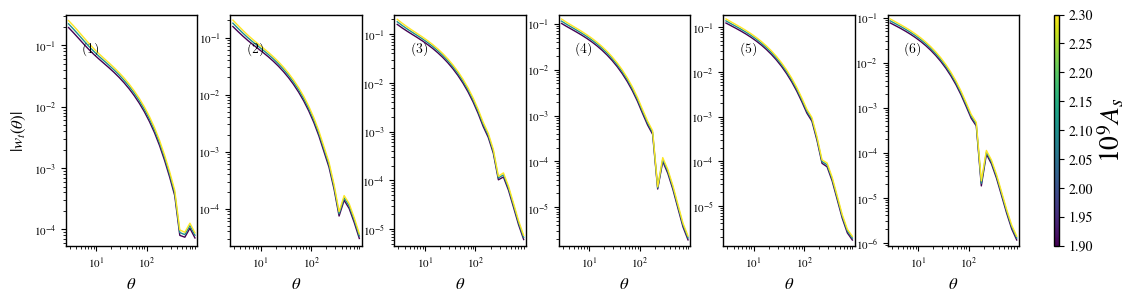

In [8]:
cnu.plot_wtheta_tomo(
    theta_wtheta=clustering_correlations,
    param=amplitudes,
    colorbarlabel=r"$10^9 A_s$",
    thetashow=[2.5, 995.2679263837432],
    cmap="viridis",
    figsize=(15, 3),
    bintextsize=10,
    xaxislabelsize=12,
    yaxislabelsize=12,
    xaxisticklabelsize=8,
    yaxisticklabelsize=8,
)


## Check accuracy and continue exploring

The shared plotters also have a ratio mode. Given a reference curve, each panel shows value/reference − 1 on one shared linear band; for example, the fractional change of γt with $A_s$ around the fiducial, within ±20%:

```python
cnu.plot_gammat_tomo_limber(
    theta_gammat=gammat_curves,
    gammat_ref=gammat_curves[1],
    param=amplitudes,
    colorbarlabel=r"$10^9 A_s$",
    ylim=[0.8, 1.2],
    thetashow=[2.5, 995.2679263837432],
)
```

To inspect another prediction, copy `fiducial`, change one sampled parameter and call `evaluate` again. Changing a likelihood option, such as the IA model, the angular binning or an accuracy setting, requires restarting the kernel and building the model from an edited YAML.

A smooth plot does not establish numerical convergence. Run `python -m pytest ./projects/des_y6/tests/data_vector` from `cocoa/Cocoa` for the accuracy, cache-consistency and frozen-reference checks. The dummy covariance cannot weight theory differences by DES observational uncertainties.


In [9]:
# Closes Cobaya's likelihood and theory components. The compiled library keeps
# its state until the kernel restarts, so restart before building another model.
model.close()
